# Lesson 4: Working with Raster Data

This notebook focuses on **raster** data, exploring raster data operations, exploration, and visualization.

## Learning Objectives:
- Work on conducting exploratory raster data analysis
- Create basic and customized visualizations of raster data
- Conduct raster operations
- Analyze spatial and temporal trends in raster data

Let's get started by loading the necessary packages!

In [15]:
# run this line of code to quickly install the necessary spatial packages
system('apt-get install r-cran-sf r-cran-terra r-cran-tidyterra r-cran-knitr')

In [16]:
# Load the required packages
library(sf)          # Simple Features - a standardized way to encode spatial vector data
library(ggplot2)     # Data visualization package
library(dplyr)       # Data manipulation package
library(terra)       # Spatial data manipulation and analysis
library(tidyterra)   # Integration of terra with the tidyverse
library(knitr)       # For nice table output

# set maximum memory usage limit for as long as your current kernel remains active
# this line has been added to your code-along notebook on top of Luke's version to adjust for computing specification differences
terraOptions(memmax = 3.5)

## Loading Raster Data

In this section, we'll load and explore raster data using the `terra` package. Raster data represents spatial information as a grid of cells or pixels, where each cell contains a value representing information such as elevation, temperature, land cover, or satellite imagery.

We'll be working with the Hansen Global Forest Change dataset, which tracks forest loss and gain globally. This dataset is stored in a GeoTIFF format (`.tif`), which is a common format for raster data that includes spatial reference information.

The `terra::rast()` function allows us to read raster data into R, creating a SpatRaster object that we can analyze and visualize.


In [17]:
# Load the Hansen Global Forest Change dataset as a raster
hansen <- terra::rast("https://github.com/yse-eds-cert/yse-eds-cert-classroom-code-along-notebooks-code_along_notebooks/raw/refs/heads/main/course-4-environmental-analysis/geospatial-data/raster/hansen.tif")

# Let's examine the basic properties of this raster
print(hansen)


class       : SpatRaster
size        : 8952, 5344, 3  (nrow, ncol, nlyr)
resolution  : 200, 200  (x, y)
extent      : -170600, 898200, 514300, 2304700  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 51N (EPSG:32651)
source      : hansen.tif
colors rgb  : 1, 2, 3
names       : treecover2000, lossyear, datamask
min values  :             0,        0,        0
max values  :           100,       23,        2


What happens if we plot the raster object?

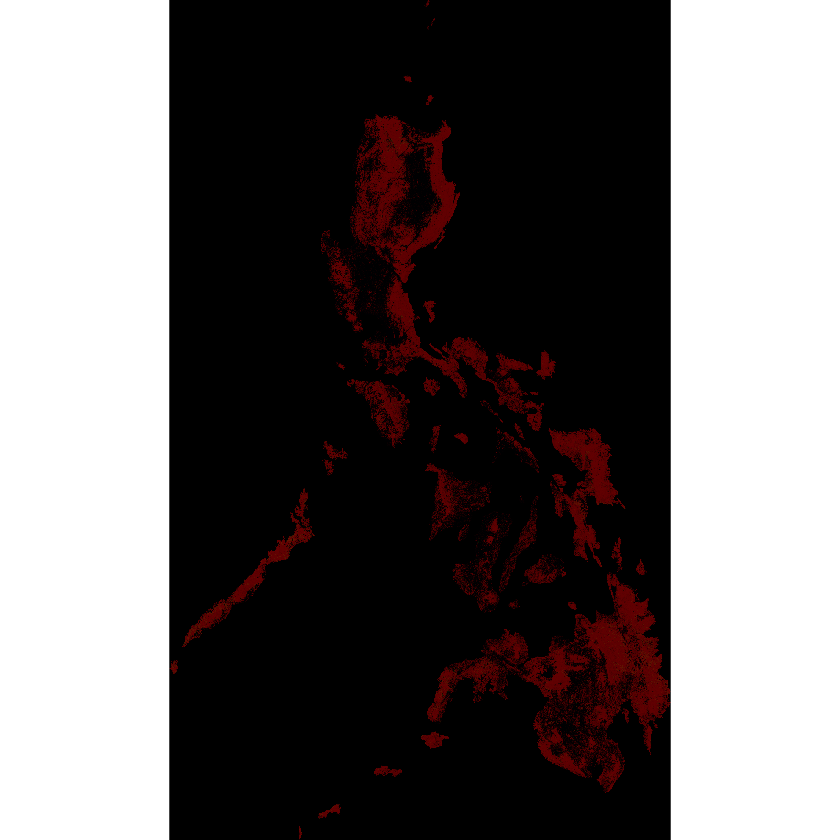

In [18]:
plot(hansen, main = "Forest Loss Year")


Hmmm, that took too long and wasn't very informative. That raster has a lot of bands and we didn't specify which one to plot! Let's try plotting some specific bands. We did this in lesson 2, but let's do it again here for the lossyear band.

class       : SpatRaster
size        : 8952, 5344, 1  (nrow, ncol, nlyr)
resolution  : 200, 200  (x, y)
extent      : -170600, 898200, 514300, 2304700  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 51N (EPSG:32651)
source      : hansen.tif
name        : lossyear
min value   :        0
max value   :       23


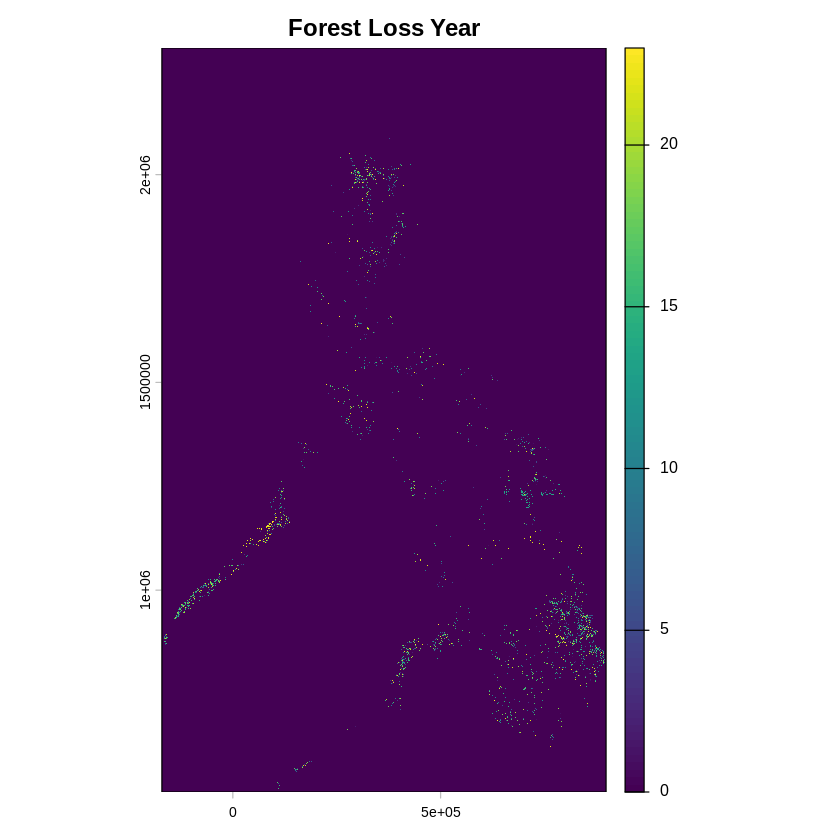

In [19]:

# Extract specific bands
treecover2000 <- hansen$treecover2000  # Tree cover percentage in the year 2000
lossyear <- hansen$lossyear # Year of forest loss (0 if no loss)

print(lossyear)

# Plot the lossyear raster
plot(lossyear, main = "Forest Loss Year")

# Alternative plot using ggplot2 with tidyterra
ggplot() +
  geom_spatraster(data = lossyear) +
  scale_fill_viridis_c(na.value = "transparent", name = "Loss Year") +
  theme_minimal() +
  labs(title = "Forest Loss Year")



Oceans have a value of 0 so we can't visually tell the difference between non-forested pixels and those that lost forest in the early years. Let's try masking out the water pixels and only using the land pixels, and only visualize pixels that experienced forest loss.

In [ ]:
# Extract datamask from hansen
datamask <- hansen$datamask

# Set lossyear to NA where datamask is not equal to 1 or where loss is 0
lossyear_masked <- lossyear
lossyear_masked[datamask != 1 | lossyear == 0 | treecover2000 == 0] <- NA

# Plot the masked lossyear raster using ggplot2 with tidyterra
ggplot() +
  geom_spatraster(data = lossyear_masked) +
  scale_fill_gradient(low = "yellow", high = "purple", na.value = "transparent", name = "Loss Year") +
  theme_minimal() +
  labs(title = "Forest Loss Year (Land Only)")


### Exercise: Plot treecover2000
Can you plot the treecover2000 raster? remember that we saved that raster layer as treecover2000. Can you borrow code from earlier to create a plot of that raster?

In [ ]:
# take a look at the treecover2000 raster
# YOUR CODE HERE

# Now set all non-land pixels to NA
# YOUR CODE HERE

# Now plot the treecover2000 raster
# YOUR CODE HERE

Now that you've successfully plotted the treecover2000 raster, let's overlay the lossyear raster on top of it. We want one color scheme for the treecover2000 raster and a different color scheme for the lossyear raster, so we need a package called `ggnewscale`.

In [ ]:
treecover2000_masked <- treecover2000
treecover2000_masked[datamask != 1] <- NA

# Now plot the treecover2000 raster
# We need to install and load the ggnewscale package to use new_scale_fill
# install.packages("ggnewscale") <- this is typically how we install packages on a local computer

# The below line is faster for installing a package on Google Colab
system('apt-get install r-cran-ggnewscale')
library(ggnewscale)

ggplot() +
  geom_spatraster(data = treecover2000_masked) +
  scale_fill_gradient(low = "black", high = "green", na.value = "transparent", name = "Tree Cover (%)") +
  theme_minimal() +
  labs(title = "Tree Cover 2000 with Forest Loss") +
  new_scale_fill() +
  geom_spatraster(data = lossyear_masked) +
  scale_fill_gradient(low = "yellow", high = "purple", na.value = "transparent", name = "Loss Year")





### Calculating Raster Statistics

We can calculate basic statistics to understand our raster data better:

In [ ]:
# Calculate summary statistics
global_summary <- global(treecover2000_masked, fun=c("min", "max", "mean", "sd"), na.rm=TRUE)
knitr::kable(global_summary, caption = "Summary Statistics of Tree Cover 2000")

# Calculate summary statistics for the lossyear raster
global_summary <- global(lossyear_masked, fun=c("min", "max", "mean", "sd"), na.rm=TRUE)
knitr::kable(global_summary, caption = "Summary Statistics of Forest Loss Year")

### Exploring the Distribution of Raster Values

Histograms are useful for understanding the distribution of values in our raster:

In [ ]:
# Create a histogram to check the distribution of values
hist(treecover2000, main="Histogram of Tree Cover Values",
     xlab="Tree Cover Percentage", col="lightgreen", breaks=20)

# Can you create a histogram of the lossyear raster?
# YOUR CODE HERE

### There's an issue with the above histograms--there is much too much area with treecover2000=0.

Let's make sure we're using the correct raster layer for the histogram.

In [ ]:
# Create a histogram to check the distribution of values
hist(treecover2000_masked, main="Histogram of Tree Cover Values",
     xlab="Tree Cover Percentage", col="lightgreen", breaks=20)

# Can you create a histogram of the lossyear raster?
hist(lossyear_masked, main="Histogram of Forest Loss Year",
     xlab="Forest Loss Year", col="lightblue", breaks=23)

### Exercise: Create a histogram showing the distribution of canopy cover for all forest loss in the year 2016.

It looks like forest loss was highest in 2016. For that year, can you create a histogram showing the distribution of forest loss by tree cover percentage?

In [ ]:
# First, create a mask for cells where forest loss occurred in 2016
loss_2016 <- lossyear_masked == 16  # Year 2016 is coded as 16 (base year 2000 + 16)
# YOUR CODE HERE

# Apply this mask to the tree cover data (use the mask function)
treecover_2016_loss <- mask(treecover2000_masked, loss_2016)
# YOUR CODE HERE

# Create a histogram of tree cover percentages for areas that experienced loss in 2016
hist(treecover_2016_loss,
     main="Tree Cover Distribution in Areas with Forest Loss in 2016",
     xlab="Tree Cover Percentage",
     col="coral",
     breaks=20)

# YOUR CODE HERE


In [ ]:
# installing required package
system('apt-get install r-cran-ggridges')

# Create a data frame for plotting with ggplot2
library(ggridges)

# Let's combine both tree cover and loss year data into a data frame
combined_df <- as.data.frame(c(treecover2000_masked, lossyear_masked), xy=TRUE, na.rm=TRUE)
names(combined_df)[3:4] <- c("tree_cover", "loss_year")

# Remove NAs and filter for valid loss years
combined_df <- combined_df %>%
  filter(!is.na(loss_year)) %>%
  mutate(actual_year = 2000 + loss_year)


# Remove NAs and filter for valid loss years
combined_df <- combined_df %>%
  filter(!is.na(loss_year)) %>%
  mutate(actual_year = 2000 + loss_year) %>%
  filter(actual_year == 2005 | actual_year == 2010 | actual_year == 2015 | actual_year == 2020)


# Create a layered histogram of tree cover for selected years, faceted vertically
ggplot(combined_df, aes(x = tree_cover, fill = factor(actual_year))) +
  geom_histogram(bins = 30) +
  facet_grid(actual_year ~ .) +
  labs(title = "Tree Cover Distribution by Forest Loss Year",
       x = "Tree Cover Percentage (Year 2000)",
       y = "Count") +
  theme_minimal() +
  scale_fill_viridis_d() +
  theme(legend.position = "none")


# Recap

In this notebook, we've accomplished the following learning objectives:

## Exploratory Raster Data Analysis
- Loaded and examined raster data (tree cover and forest loss)
- Calculated summary statistics for raster datasets
- Masked rasters to focus on specific areas of interest

## Raster Visualization
- Created basic histograms of raster values
- Developed customized visualizations with proper titles and styling
- Used ggplot2 to create more complex visualizations of raster data
- Implemented faceted plots to compare distributions across different years

## Raster Operations
- Performed masking operations to extract specific data subsets
- Conducted reclassification to focus on particular years of forest loss
- Combined multiple raster layers for integrated analysis

## Spatial and Temporal Trend Analysis
- Analyzed the distribution of tree cover in areas with forest loss
- Compared forest loss patterns across different years (2005, 2010, 2015, 2020)
- Visualized how tree cover values relate to forest loss timing
